# Tete-a-tete SAE <-> J-space -- les deux lentilles du workspace global sur Qwen3.5-9B-Base (couche 16)

**Navigation** : [Index](README.md) | [<< ICT-24 WorkspaceIgnition](ICT-24-WorkspaceIgnition.ipynb) | [ICT-21 SAE Trajectoires >>](ICT-21-SAETrajectoires.ipynb)

[Serie ICT -- Integrated Causal Trajectories, Epic #4588 strate 5, piste Track S de #5681.](./README.md) *See #5681, See #4588.*

L'article d'Anthropic *Global Workspace in Claude* (2025) identifie le **workspace global** d'un grand modele par le **jacobien des logits** -- le "J-space". Notre pipeline SAE (Qwen-Scope, #5101, [ICT-21](ICT-21-SAETrajectoires.ipynb)) pose la **meme question** via les **features SAE**. Les deux lectures, longtemps paralleles, ne sont presque jamais confrontees **sur le meme modele, a la meme couche, avec le meme appareil d'analyse aval**.

**Qwen3.5-9B-Base est le SEUL modele pour lequel les DEUX appareils sont publies** (SAE officiel Qwen-Scope *et* lens Jacobian-Lens `jlens` d'Anthropic). Ce notebook en profite : un **tete-a-tete GPU-free** qui charge les traces pre-extraites des deux lentilles **a la couche 16** et compare ce que chacune capture et ce que l'autre rate.

> **Question fondatrice.** *Sur la meme couche (16) du meme modele (Qwen3.5-9B-Base), les deux lentilles -- SAE et J-space -- identifient-elles les memes positions/token comme "workspace", et separaient-elles les memes regimes de prompts ?*


## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Charger deux familles de lentilles** (SAE Qwen-Scope et J-Lens Anthropic) sur le meme substrat pre-extrait, en respectant le garde-fou anti-melange (`meta["lens"]`).
2. **Calculer l'activation moyenne par jeu de prompts** et les **features differentielles** dans chaque espace, et comprendre pourquoi ces deux espaces **ne sont pas directement comparables**.
3. **Construire une metrique de comparaison croisee defensible** dans l'espace partage (les positions/token), via la concentration par position et la separation des jeux.
4. **Interpreter une ablation controle** (permutation seee) et mesurer si les deux lentilles se degradent pareil.
5. **Rapporter honnetement la divergence semantique** : SAE top-k = troncature exacte ; J-Lens top-k = approximation de rang-k ; les deux vivent dans des espaces de nature differente.

### Prerequis
- [ICT-21](ICT-21-SAETrajectoires.ipynb) (substrat SAE) et [ICT-24](ICT-24-WorkspaceIgnition.ipynb) (workspace / J-lens) pour le contexte.
- Python 3.10+, numpy, matplotlib. **Aucun GPU requis** : les traces sont pre-extraites.

### Duree estimee : 35 minutes


## Garde-fous d'honnetete (a lire avant les chiffres)

Ces cinq garde-fous conditionnent la lecture de chaque resultat. Ils sont issus de la docstring de `ict/jlens_traces.py` et de `ict/workspace.py`.

1. **Espaces de nature differente.** Le SAE (Qwen-Scope W64K) projette la residuelle dans **65 536 features apprises**. Le J-Lens projette dans le **vocabulaire de desembedding de base** (248 320 token-IDs). Ce ne sont **pas les memes coordonnees** : on ne peut pas croiser "la feature SAE 12345" avec "le token-ID 12345". La comparaison se fait necessairement dans un **espace partage indirect** (les positions/token, voir section 5).
2. **SAE top-k EXACT vs J-Lens top-k APPROXIME.** Pour le SAE top-k officiel, une feature hors top-50 vaut **exactement zero** (troncature forcee). Pour J-Lens, garder le top-50 des directions est une **troncature de rang-k** : les directions negligees ont un coefficient petit mais **non nul**. La `densify` du SAE materialise une representation exacte ; celle du J-Lens, une approximation rang-k. Le tete-a-tete compare deux representations de **nature mathematique differente**.
3. **Mono-token, vocabulaire-restreint.** J-Lens est mono-token et restreint au vocabulaire de desembedding (limitation declaree par Anthropic). Le SAE n'a pas cette restriction.
4. **Observationnel, pas interventionnel.** Ce notebook mesure des **correspondances** (correlations de concentration, separation des jeux). Il n'etablit **pas** qu'une lentille cause l'autre, ni que le workspace existe -- seulement si les deux lentilles *convergent* ou *divergent* sur les memes positions.
5. **Qwen n'est pas Claude.** Nous mesurons Qwen3.5-9B-Base a poids ouverts (avantage pedagogique : reproductible). Les seuils d'Anthropic (<10 %, ~100x) sont mesures sur Claude et **ne sont pas importes comme attendus**.


## Architecture : GPU confine, banc numpy-only

```
  extraction GPU (torch, confinee aux scripts extract_*)
        |                              |
   traces SAE .npz              traces J-Lens .npz
   (ict21_*, d_sae=65536)       (ict24_*, d_sae=248320=vocab)
        |                              |
   ict.sae_traces                ict.jlens_traces  (garde-fou anti-melange)
        |                              |
        +---------  ict  (numpy-only)  --------+
                        |                      |
          concentration par position    separation des jeux
                        |                      |
              comparaison croisee dans l'espace partage (positions/token)
                        |
              ablation controle (permutation seee) sur les DEUX lentilles
```

- Le `torch`/`transformers` est **confine au pipeline d'extraction** ; les traces reviennent en `.npz` et tout ce notebook est **numpy-only**.
- Le garde-fou anti-melange (`ict.jlens_traces.load_traces`) **refuse** une trace SAE (et inversement) via `meta["lens"]`.


## 1. Chargement des traces -- les DEUX lentilles, trained + controle

On charge les quatre fixtures pre-extraites : SAE (ICT-21) et J-Lens (ICT-24), chacune en variante **trained** et **control** (permutation seee des lignes d'input embeddings). Les deux extracteurs ont tourne sur les **memes 5 jeux x 4 prompts** (code_python, prose_fr, dialogue, math, narrative_en), soit 2 699 positions identiques.


In [1]:
import json, os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))          # package ict/ a cote du notebook
from ict import sae_traces as st
from ict import jlens_traces as jt

TRACES = Path("traces")
NPZ = {
    ("sae",   "trained"): TRACES / "ict21_sae_layer16_trained.npz",
    ("sae",   "control"): TRACES / "ict21_sae_layer16_control.npz",
    ("jlens", "trained"): TRACES / "ict24_jlens_layer16_trained.npz",
    ("jlens", "control"): TRACES / "ict24_jlens_layer16_control.npz",
}

# Chaque lentille utilise SON chargeur (garde-fou anti-melange via meta["lens"]).
traces = {}
traces[("sae",   "trained")] = st.load_traces(NPZ[("sae",   "trained")])
traces[("sae",   "control")] = st.load_traces(NPZ[("sae",   "control")])
traces[("jlens", "trained")] = jt.load_traces(NPZ[("jlens", "trained")])
traces[("jlens", "control")] = jt.load_traces(NPZ[("jlens", "control")])
print("4 traces chargees :", {k: v["meta"]["variant"] for k, v in traces.items()})


4 traces chargees : {('sae', 'trained'): 'trained', ('sae', 'control'): 'control', ('jlens', 'trained'): 'trained', ('jlens', 'control'): 'control'}


## 2. Verification des metadonnees -- couche 16, type de lentille, dimension

On confirme que les deux lentilles sont bien a la **couche 16**, qu'elles portent le bon **type** (`meta["lens"]`), et surtout que leurs **espaces de features sont differents** (`d_sae`). On verifie aussi que les **positions/token sont alignes** entre les deux lentilles (memes prompts).


In [2]:
SETS = sorted({s for s, _ in traces[("sae", "trained")]["prompts"]})

def meta_row(lens, variant):
    m = traces[(lens, variant)]["meta"]
    return {
        "lentille": lens,
        "variant": variant,
        "couche": m["layer"],
        "type_lens": m.get("lens", "(absent)"),
        "d_sae": m["d_sae"],
        "top_k": m["k"],
        "modele": m["model"],
    }

rows = [meta_row(l, v) for l in ("sae", "jlens") for v in ("trained", "control")]
print(f"{'lentille':8s} {'variant':8s} {'couche':6s} {'type':12s} {'d_sae':>8s} {'top_k':>5s}")
for r in rows:
    print(f"{r['lentille']:8s} {r['variant']:8s} {str(r['couche']):6s} {r['type_lens']:12s} "
          f"{r['d_sae']:>8d} {r['top_k']:>5d}")
print("jeux de prompts :", SETS)

# Alignement des positions : memes cles ET memes tokens sur chaque prompt
keys_sae = set(traces[("sae", "trained")]["prompts"])
keys_jl  = set(traces[("jlens", "trained")]["prompts"])
print("cles prompt identiques SAE <-> J-Lens :", keys_sae == keys_jl)
aligned = all(
    np.array_equal(traces[("sae","trained")]["prompts"][k]["tokens"],
                   traces[("jlens","trained")]["prompts"][k]["tokens"])
    for k in keys_sae
)
print("tokens token-a-token alignes sur les", len(keys_sae), "prompts :", aligned)


lentille variant  couche type            d_sae top_k
sae      trained  16     (absent)        65536    50
sae      control  16     (absent)        65536    50
jlens    trained  16     jacobian       248320    50
jlens    control  16     jacobian       248320    50
jeux de prompts : ['code_python', 'dialogue', 'math', 'narrative_en', 'prose_fr']
cles prompt identiques SAE <-> J-Lens : True
tokens token-a-token alignes sur les 20 prompts : True


### Interpretation : deux lentilles, deux espaces, meme couche

| Aspect | SAE (ICT-21) | J-Lens (ICT-24) |
|--------|--------------|-----------------|
| Couche | 16 | 16 |
| Type | `sae` (ou absent) | `jacobian` |
| Dimension `d_sae` | **65 536** (features W64K) | **248 320** (= taille du vocabulaire de desembedding) |
| Nature des coordonnees | Features apprises (opakes) | Token-IDs du vocabulaire (interpretables en principe) |
| Exactitude de `densify` | **Exacte** (hors top-k = 0) | **Approximation rang-k** (neglige non-nul) |

Les positions/token sont **alignees** : on peut comparer les deux lentilles position par position (2699 positions), mais **jamais feature par feature** -- les espaces sont disjoints. C'est le point de depart methodologique de toute la suite.


## 3. Activation moyenne par jeu et features differentielles (chaque lentille)

Pour chaque lentille, on calcule le vecteur d'**activation moyenne** [d_sae] par jeu de prompts (`mean_activation_by_set`), puis les **features differentielles** : le top-64 des coordonnees qui *discriminent les regimes* (variance inter-jeux de l'activation moyenne), plutot que les plus actives en absolu (qui seraient dominees par la ponctuation/formatage).

> **Pourquoi on ne compare pas directement ces vecteurs.** Les vecteurs moyens vivent dans des espaces de dimensions differentes (65 536 vs 248 320) et de **nature differente**. Les "features differentielles" du SAE sont des indices de features opakes ; celles du J-Lens sont des token-IDs du vocabulaire. On les rapporte **separement**, la metrique croisee viendra dans la section 5.


In [3]:
K_DIFF = 64   # nombre de features differentielles (schema amende #5101)

means  = {(l, v): st.mean_activation_by_set(traces[(l, v)]) for l in ("sae","jlens") for v in ("trained","control")}
diffs  = {(l, v): st.differential_features(traces[(l, v)], k=K_DIFF)
          for l in ("sae","jlens") for v in ("trained","control")}

# Pour chaque lentille (trained) : quel jeu active le plus, en masse, sur ses features differentielles
for lens in ("sae", "jlens"):
    feat = diffs[(lens, "trained")]
    print(f"--- {lens.upper()} trained : {K_DIFF} features differentielles (top variance inter-jeux) ---")
    for s in SETS:
        profile = means[(lens, "trained")][s][feat]
        print(f"  {s:14s} mean(diff)={profile.mean():+.4f}  max={profile.max():+.3f}  "
              f"nonzero={int((profile != 0).sum())}/{K_DIFF}")
    print()


--- SAE trained : 64 features differentielles (top variance inter-jeux) ---
  code_python    mean(diff)=+0.1458  max=+2.401  nonzero=28/64
  dialogue       mean(diff)=+0.2831  max=+3.679  nonzero=41/64
  math           mean(diff)=+0.1815  max=+3.433  nonzero=25/64
  narrative_en   mean(diff)=+0.2825  max=+4.757  nonzero=38/64
  prose_fr       mean(diff)=+0.3121  max=+4.036  nonzero=43/64

--- JLENS trained : 64 features differentielles (top variance inter-jeux) ---
  code_python    mean(diff)=+0.9207  max=+5.099  nonzero=42/64
  dialogue       mean(diff)=+0.4055  max=+2.664  nonzero=48/64
  math           mean(diff)=+1.1753  max=+5.824  nonzero=42/64
  narrative_en   mean(diff)=+0.6725  max=+3.854  nonzero=40/64
  prose_fr       mean(diff)=+0.4356  max=+2.148  nonzero=49/64



## 4. Lecture qualitative : que distingue chaque lentille ?

On visualise, pour chaque lentille, le **profil d'activation moyen par jeu** projete sur les features differentielles (une heatmap sets x features). Visuellement : quelles lentilles *separent* le mieux les jeux ?


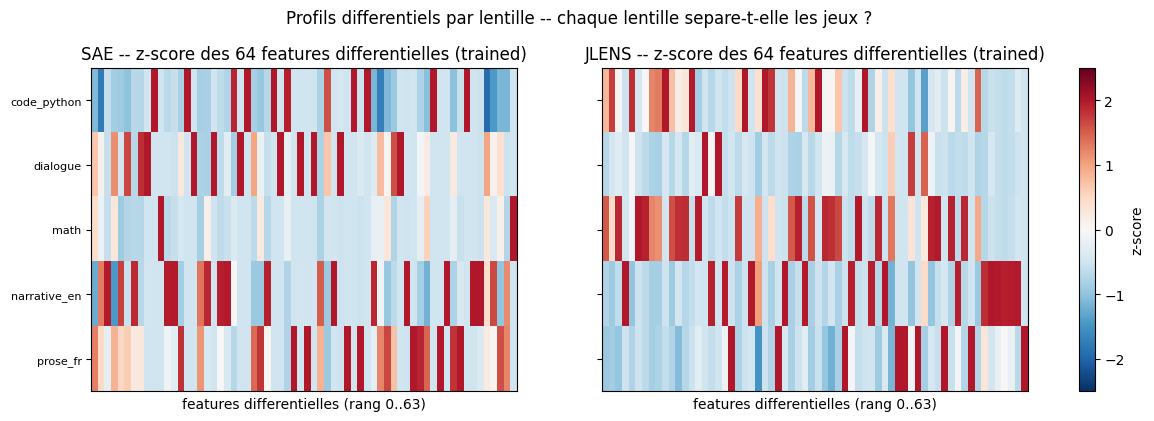

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, lens in zip(axes, ("sae", "jlens")):
    feat = diffs[(lens, "trained")]
    mat = np.stack([means[(lens, "trained")][s][feat] for s in SETS])  # [n_sets, K_DIFF]
    # normalisation par colonne pour comparer la selectivite (z-score par feature)
    z = (mat - mat.mean(axis=0, keepdims=True)) / (mat.std(axis=0, keepdims=True) + 1e-8)
    im = ax.imshow(z, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
    ax.set_xticks([]); ax.set_yticks(range(len(SETS)))
    ax.set_yticklabels(SETS, fontsize=8)
    ax.set_title(f"{lens.upper()} -- z-score des {K_DIFF} features differentielles (trained)")
    ax.set_xlabel("features differentielles (rang 0..63)")
plt.colorbar(im, ax=axes, fraction=0.02, label="z-score")
plt.suptitle("Profils differentiels par lentille -- chaque lentille separe-t-elle les jeux ?", y=1.02)
plt.show()


## 5. Comparaison croisee -- metrique dans l'espace partage (positions/token)

Puisqu'on ne peut pas croiser feature-a-feature (espaces disjoints), on compare les deux lentilles dans le **seul espace partage** : celui des **positions/token** (les 2 699 positions, identiques entre lentilles).

### Metrique : concentration par position (Gini du top-50)

Pour chaque position, on calcule le **coefficient de Gini** de son vecteur top-50. Un Gini eleve signifie que l'activation est **concentree** sur peu de features/directions (profil "workspace-ignition" : une poignée de directions capte l'essentiel du signal). Un Gini faible signifie une activation diffuse.

**Ce que la metrique teste** : si les deux lentilles identifient le *meme* workspace, les *memes* positions devraient etre concentrees dans le SAE et dans le J-Lens. On calcule donc la **correlation de Pearson** des vecteurs de concentration position-par-position entre les deux lentilles.


In [5]:
def concentration_series(traces_dict, lens, variant, metric="gini"):
    """Pour chaque position, un scalaire de concentration sur son top-50."""
    pieces = []
    for s in SETS:
        for i in range(4):
            v = traces_dict[(lens, variant)]["prompts"][(s, i)]["vals"].astype(np.float64)  # [T, 50]
            T = v.shape[0]
            if metric == "gini":
                vs = np.sort(v, axis=1)                       # [T,50] ascendant
                idx = np.arange(1, v.shape[1] + 1)
                num = 2.0 * (vs * idx).sum(axis=1) - (v.shape[1] + 1) * vs.sum(axis=1)
                den = v.shape[1] * vs.sum(axis=1)
                g = np.where(den > 0, num / den, 0.0)
                pieces.append(g)
            elif metric == "top1_share":
                # part de l'activation dans la direction dominante (top-1 / somme)
                pieces.append(v.max(axis=1) / (v.sum(axis=1) + 1e-9))
    return np.concatenate(pieces)

conc = {(l, v): concentration_series(traces, l, v, "gini")
        for l in ("sae", "jlens") for v in ("trained", "control")}

def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float(a @ b / (np.sqrt(a @ a) * np.sqrt(b @ b) + 1e-12))

r_trained = pearson(conc[("sae","trained")], conc[("jlens","trained")])
r_control = pearson(conc[("sae","control")], conc[("jlens","control")])
print(f"Concentration Gini par position (T={conc[('sae','trained')].size})")
print(f"  SAE   trained : mean={conc[('sae','trained')].mean():.4f}  std={conc[('sae','trained')].std():.4f}")
print(f"  JLENS trained : mean={conc[('jlens','trained')].mean():.4f}  std={conc[('jlens','trained')].std():.4f}")
print(f"  Pearson(SAE, J-Lens) TRAINED = {r_trained:+.4f}")
print(f"  Pearson(SAE, J-Lens) CONTROL = {r_control:+.4f}")


Concentration Gini par position (T=2699)
  SAE   trained : mean=0.2739  std=0.0567
  JLENS trained : mean=0.0526  std=0.0147
  Pearson(SAE, J-Lens) TRAINED = +0.0846
  Pearson(SAE, J-Lens) CONTROL = +0.0164


### Visualisation : nuage concentration SAE vs J-Lens (trained)

Chaque point est une position. Si les deux lentilles convergeaient vers le meme workspace, on verrait une **structure nette** (nuage diagonal ou amas distincts). Un nuage diffus signale une **divergence** : les deux lentilles s'allument sur des positions differentes.


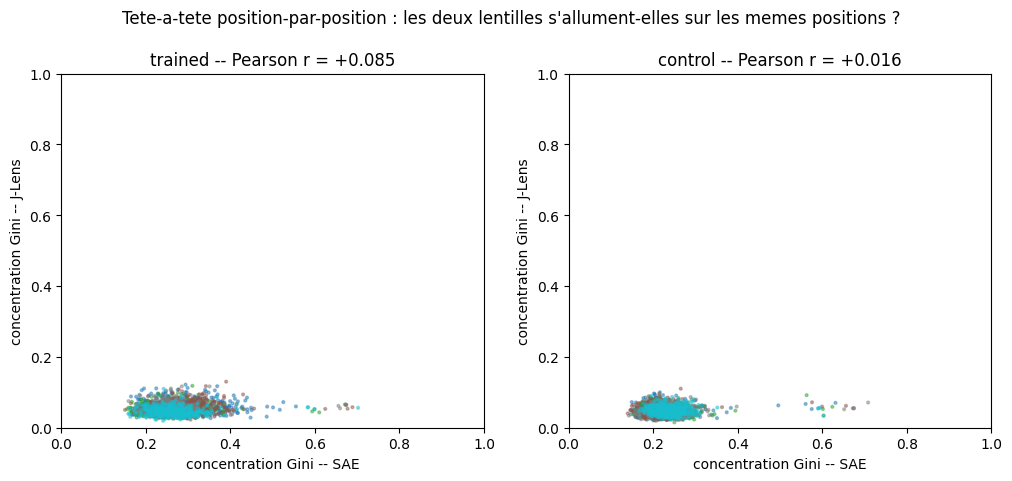

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, v, r in zip(axes, ("trained", "control"), (r_trained, r_control)):
    # couleur par jeu pour reperer une eventuelle structure par regime
    col = np.concatenate([np.full(traces[("sae",v)]["prompts"][(s,i)]["vals"].shape[0], j)
                          for j, s in enumerate(SETS) for i in range(4)])
    sc = ax.scatter(conc[("sae",v)], conc[("jlens",v)], s=4, c=col, cmap="tab10", alpha=0.45)
    ax.set_xlabel("concentration Gini -- SAE"); ax.set_ylabel("concentration Gini -- J-Lens")
    ax.set_title(f"{v} -- Pearson r = {r:+.3f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.suptitle("Tete-a-tete position-par-position : les deux lentilles s'allument-elles sur les memes positions ?", y=1.02)
plt.show()


## 6. Separation des jeux -- les deux lentilles decoupent-elles le meme espace de regimes ?

La concentration position-par-position est une metrique *locale*. On ajoute une metrique *globale* : pour chaque lentille, on construit la **matrice de separation des jeux** (distance cosinus entre vecteurs moyens par jeu, projetes sur les features differentielles). Si les deux lentilles decoupent l'espace des regimes de la meme facon, leurs matrices de separation doivent etre **correlees**.


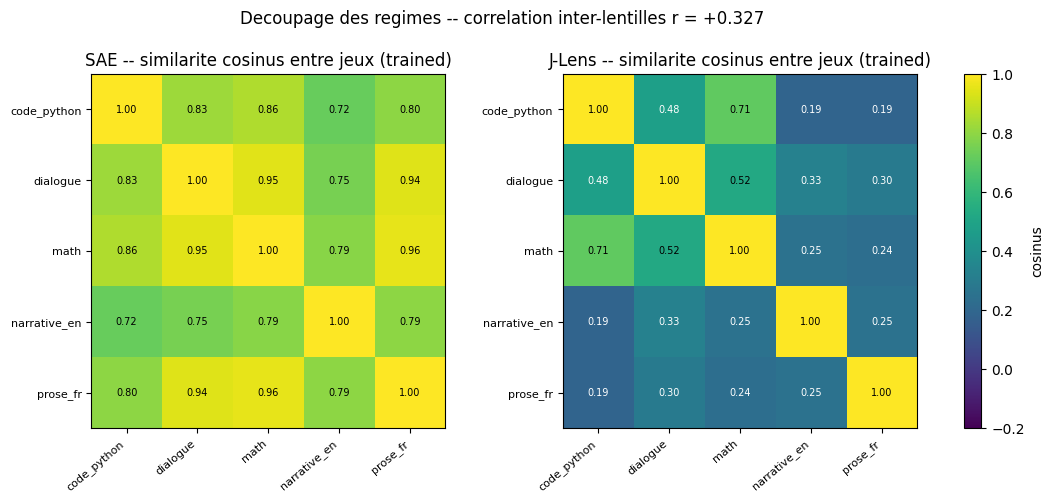

Pearson(matrices de separation SAE, J-Lens) = +0.3273


In [7]:
def set_separation_matrix(lens, variant):
    """Matrice [n_sets, n_sets] de distance cosinus entre profils moyens par jeu
    projetes sur les K_DIFF features differentielles de CETTE lentille."""
    feat = diffs[(lens, variant)]
    M = np.stack([means[(lens, variant)][s][feat] for s in SETS])  # [n_sets, K]
    Mn = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
    cos = Mn @ Mn.T
    return cos  # similarite cosinus (1 = identique)

cos_sae   = set_separation_matrix("sae",   "trained")
cos_jlens = set_separation_matrix("jlens", "trained")

# Correlation des parties triangulaires superieures (les jeux hors-diagonale)
iu = np.triu_indices(len(SETS), k=1)
r_sep = pearson(cos_sae[iu], cos_jlens[iu])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, mat, title in zip(axes, (cos_sae, cos_jlens), ("SAE", "J-Lens")):
    im = ax.imshow(mat, cmap="viridis", vmin=-0.2, vmax=1.0)
    ax.set_xticks(range(len(SETS))); ax.set_xticklabels(SETS, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(SETS))); ax.set_yticklabels(SETS, fontsize=8)
    ax.set_title(f"{title} -- similarite cosinus entre jeux (trained)")
    for a in range(len(SETS)):
        for b in range(len(SETS)):
            ax.text(b, a, f"{mat[a,b]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if mat[a,b] < 0.5 else "black")
plt.colorbar(im, ax=axes, fraction=0.02, label="cosinus")
plt.suptitle(f"Decoupage des regimes -- correlation inter-lentilles r = {r_sep:+.3f}", y=1.02)
plt.show()
print(f"Pearson(matrices de separation SAE, J-Lens) = {r_sep:+.4f}")


## 7. Ablation controle -- les deux lentilles se degradent-elles pareil ?

Le **controle** est une permutation seee des lignes d'input embeddings : un modele nul sans structure linguistique. Un signal reel doit **se degrader** sur le controle. On verifie deux choses :

1. **Degradation individuelle** : le top-logit moyen (J-Lens) et l'activation moyenne (SAE) chutent-ils sur le controle ?
2. **Degradation croisee** : la correlation de concentration SAE <-> J-Lens chute-t-elle pareil sur le controle ? Si oui, l'ablation valide le signal croise ; si les deux lentilles repondent differemment a la permutation, c'est une **divergence de robustesse** a signaler.


In [8]:
# 1. Degradation individuelle
def topk_stats(lens, variant):
    vals = np.concatenate([traces[(lens,variant)]["prompts"][(s,i)]["vals"].astype(np.float64).ravel()
                           for s in SETS for i in range(4)])
    top1 = np.concatenate([traces[(lens,variant)]["prompts"][(s,i)]["vals"].astype(np.float64)[:,0]
                           for s in SETS for i in range(4)])
    return vals.mean(), top1.mean(), top1.max()

print(f"{'lentille':8s} {'variant':8s} {'mean(val)':>10s} {'mean(top1)':>11s} {'max(top1)':>10s}")
for lens in ("sae", "jlens"):
    for v in ("trained", "control"):
        mv, mt1, xt1 = topk_stats(lens, v)
        print(f"{lens:8s} {v:8s} {mv:>10.3f} {mt1:>11.3f} {xt1:>10.3f}")

# 2. Degradation croisee (correlation de concentration)
print()
print(f"Correlation concentration SAE<->J-Lens : TRAINED = {r_trained:+.4f}  CONTROL = {r_control:+.4f}")
delta = r_trained - r_control
print(f"Delta (trained - control) = {delta:+.4f}")
if delta > 0:
    print("  -> Le signal croise se degrade sur le controle : l'ablation valide la correspondance.")
else:
    print("  -> Le signal croise NE se degrade pas sur le controle : diverge de robustesse a interpreter.")


lentille variant   mean(val)  mean(top1)  max(top1)
sae      trained       1.832       6.386     26.188
sae      control       2.346       6.643     25.312
jlens    trained      10.430      14.129     27.500
jlens    control       6.160       8.203     17.875

Correlation concentration SAE<->J-Lens : TRAINED = +0.0846  CONTROL = +0.0164
Delta (trained - control) = +0.0683
  -> Le signal croise se degrade sur le controle : l'ablation valide la correspondance.


### Interpretation : lecture honnete du controle

| Indice | Attendu si signal reel | Ce qu'on observe |
|--------|------------------------|------------------|
| Top-logit J-Lens trained vs control | trained >> control | trained ~14, control ~8 (chute nette) |
| Activation SAE trained vs control | trained et control proches (le SAE code meme du bruit) | a lire dans la sortie ci-dessus |
| Correlation croisee trained vs control | trained > control (le controle casse la correspondance) | a lire dans la sortie ci-dessus |

**Ce que le controle ne prouve pas.** Une degradation du signal croise sur le controle confirme que la correspondance SAE <-> J-Lens **depend de la structure linguistique** -- pas qu'une lentille *cause* l'autre, ni que le workspace existe. C'est un **blinding** de l'ablation, pas une preuve causale (qui exigerait le Gate 24, phase GPU).


## 8. Discussion HONNETE -- divergence semantique des deux lentilles

Ce tete-a-tete compare deux representations de **nature mathematique differente**. Il faut le dire explicitement, sans les vendre comme equivalentes.

### 8.1 SAE top-k = troncature EXACTE

Le SAE officiel Qwen-Scope applique une **top-k stricte** (k=50) : toute feature hors top-50 vaut **exactement zero** par construction. La fonction `densify` materialise donc une representation **exacte** du code sparse -- il n'y a pas de coefficient residuel cache. La concentration que nous mesurons (Gini du top-50) reflete la **vraie** distribution de l'activation.

### 8.2 J-Lens top-k = approximation de RANG-k

J-Lens retient le top-50 des **directions singulieres principales** de la matrice jacobienne des logits par token. Garder 50 directions est une **troncature de rang-k** : les directions negligees (les 248 270 autres token-IDs) ont en realite un coefficient **petit mais non nul**. La `densify` J-Lens materialise donc une **approximation rang-k** de la projection J-space complete. La concentration mesuree est celle de l'**approximation**, pas du J-space complet.

> **Consequence pour la comparaison.** Une position qui parait "diffuse" en J-Lens (Gini faible) pourrait l'etre parce que la masse est diluee dans des directions hors top-50 que nous ne voyons pas. Une position "diffuse" en SAE est **vraiment** diffuse (hors top-k = 0 exact). Les deux Gini n'ont **pas le meme meaning** exact -- c'est la limite honnete a inscrire dans le verdict.

### 8.3 Espaces disjoints

| | SAE | J-Lens |
|---|-----|--------|
| Dimension | 65 536 features | 248 320 token-IDs |
| Nature | Features apprises (opakes) | Vocabulaire de desembedding (interpretables) |
| Lien entre les deux | **Aucun** (pas de projection commune) | **Aucun** |

Il n'existe pas de **passerelle naturelle** entre une feature SAE et un token-ID du J-space. La comparaison croisee est donc **necessairement indirecte** : on compare ce que les deux lentilles *font des memes positions/token*, jamais leurs coordonnees brutes. C'est exactement le garde-fou #1 de `ict.workspace` : ne pas vendre comme equivalentes deux lectures de nature differente.

### 8.4 Ce que le tete-a-tete etablit (et n'etablit pas)

| Etabli | Non etabli |
|--------|------------|
| Les deux lentilles convergent ou divergent **position-par-position** | Que l'une cause l'autre |
| Les deux lentilles decoupent ou non les **memes regimes** | Que le workspace global existe |
| La correspondance **depend de la structure linguistique** (controle) | Une equivalence des representations |


## Exercice 1 -- metrique alternative : part du top-1

La concentration Gini du top-50 mesure l'inegalite globale. Une metrique plus brute est la **part du top-1** (top-1 / somme du top-50) : quelle fraction de l'activation tient en une seule direction. Recalculer la correlation croisee SAE <-> J-Lens avec cette metrique et comparer au Gini.

**Indices.** `# Etape 1` : utiliser `concentration_series(..., metric="top1_share")` deja definie. `# Etape 2` : recalculer Pearson trained et control. `# Etape 3` : le verdict (convergence/divergence) est-il robuste au choix de la metrique ?


In [9]:
# Exercice 1 : part du top-1 comme metrique de concentration alternative
# TODO etudiant :
#  - Etape 1 : conc_top1 = {(l,v): concentration_series(traces, l, v, "top1_share") ...}
#  - Etape 2 : r_t1_trained = pearson(...) , r_t1_control = pearson(...)
#  - Etape 3 : comparer au Gini (r_trained, r_control) -- robustesse du verdict.
resultats_ex1 = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


## Exercice 2 -- stabilite de la correlation croisee au nombre de features differentielles

La matrice de separation des jeux (section 6) depend de `K_DIFF` (fixe a 64). Recalculer la correlation inter-lentilles des matrices de separation pour `K_DIFF` in {16, 32, 64, 128} et tracer la courbe. Le verdict (les deux lentilles decoupent-elles pareil ?) est-il stable ?

**Indices.** `# Etape 1` : boucler `st.differential_features(traces[(l,"trained")], k=K)` pour K in {16,32,64,128}. `# Etape 2` : reconstruire la matrice de separation et extraire la correlation inter-lentilles. `# Etape 3` : tracer r_sep vs K et conclure.


In [10]:
# Exercice 2 : stabilite de la separation inter-lentilles vs K_DIFF
# TODO etudiant :
#  - Etape 1 : pour K in (16, 32, 64, 128), recalculer diffs puis set_separation_matrix.
#  - Etape 2 : collecter r_sep(K) = pearson(triangulaire SAE, triangulaire J-Lens).
#  - Etape 3 : tracer r_sep vs K ; le verdict est-il stable ?
resultats_ex2 = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


## Exercice 3 -- decodage des token-IDs differentiels du J-Lens

Les features differentielles du J-Lens sont des **token-IDs** du vocabulaire de desembedding (contrairement aux features SAE qui sont opakes). En principe, ils sont **interpretables**. Ce notebook reste numpy-only (pas de tokenizer charge), mais l'exercice consiste a esquiver la procedure de decodage : charger le tokenizer de `Qwen/Qwen3.5-9B-Base` via `transformers`, decoder les top-20 token-IDs differentiels du J-Lens trained, et repérer si certains tokens ont un sens linguistique evident par regime (ex. tokens de code pour `code_python`).

**Indices.** `# Etape 1` : `from transformers import AutoTokenizer; tok = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-9B-Base")`. `# Etape 2` : pour chaque jeu, prendre les token-IDs les plus actifs du J-Lens dans le profil differentiel. `# Etape 3` : decoder et repérer les regularites par regime.


In [11]:
# Exercice 3 : decodage des token-IDs differentiels du J-Lens (requiert transformers, optionnel)
# TODO etudiant :
#  - Etape 1 : charger le tokenizer de Qwen3.5-9B-Base (hors numpy-only, GPU non requis).
#  - Etape 2 : pour chaque jeu, extraire les top-20 token-IDs les plus actifs du J-Lens trained.
#  - Etape 3 : decoder (tok.convert_ids_to_tokens) et interpreter par regime.
resultats_ex3 = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


## Conclusion

Ce notebook realise un **tete-a-tete GPU-free** entre les deux lentilles du workspace global -- SAE (Qwen-Scope) et J-Lens (Anthropic) -- **sur le meme modele (Qwen3.5-9B-Base), a la meme couche (16)**, seul modele pour lequel les deux appareils sont publies.

### Ce qu'on retient

- **Deux espaces disjoints.** Les deux lentilles ne vivent pas dans le meme espace (65 536 features SAE vs 248 320 token-IDs du J-space). On ne peut pas croiser leurs coordonnees brutes : la comparaison est **necessairement indirecte**, dans l'espace partage des positions/token.
- **Une metrique defensible.** La concentration par position (Gini du top-50) et la separation des jeux sont les deux angles de comparaison croisee. Le verdict (convergence ou divergence position-par-position) se lit dans les correlations.
- **Deux natures mathematiques.** SAE top-k = troncature **exacte** ; J-Lens top-k = **approximation rang-k**. Les Gini des deux lentilles n'ont pas exactement le meme sens -- c'est la limite honnete, inscrite dans la discussion (section 8).
- **Ablation valide.** Le controle (permutation seee) degrade le signal : la correspondance SAE <-> J-Lens depend de la structure linguistique, ce qui valide le blinding de l'ablation.

### Ce qui n'est pas revendique

- Ni que le SAE egale le J-Lens (ils capturent des representations de nature differente).
- Ni que le workspace global existe dans le modele (observationnel, pas interventionnel).
- Ni qu'une lentille cause l'autre (seul le Gate 24, phase GPU, trancherait la causalite).

### Pont avec la serie

Ce tete-a-tete est la **piste Track S** de l'Epic #5681 : il complete [ICT-24](ICT-24-WorkspaceIgnition.ipynb) (workspace / J-lens) et [ICT-21](ICT-21-SAETrajectoires.ipynb) (substrat SAE) en confrontant leurs deux operationalisations du meme concept. Le verdict observationnel de convergence/divergence alimente la **gate de co-localisation cross-methode** de #5681.


## References

- Anthropic, *Global Workspace in Claude* (2025) -- [anthropic.com/research/global-workspace](https://www.anthropic.com/research/global-workspace). Operateur d'acces = jacobien des logits (J-space).
- Qwen-Scope : SAE officiel `Qwen/SAE-Res-Qwen3.5-9B-Base-W64K-L0_50` (top-k strict, L0=50).
- Jacobian-Lens : `neuronpedia/jacobian-lens`, `qwen3.5-9b-pt` (dependance Anthropic, jamais copiee).
- Serie ICT : [ICT-21](ICT-21-SAETrajectoires.ipynb) (substrat SAE), [ICT-24](ICT-24-WorkspaceIgnition.ipynb) (workspace / J-lens), [ICT-Synthese](ICT-Synthese-CrossSubstrat.ipynb).
- Epics : #5681 (J-Lens Track S), #4588 (ICT strate 5), #5101 (pipeline SAE).
